**This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.**

## **Problem Statement**

**Context:** This data set contains historical data of the customers who have taken loans from a German bank and the bank is facing issues with loan defaulters. The bank intends to build a machine learning model to predict whether the customer will default or not based on historical data

**Data Description:** The bank has historical information on relevant features for each customer such as employment duration, existing loans count, saving balance, percentage of income, age, default status. 
The data set has 17 columns and 1000 rows. Columns are described below and each row is a customer. 

1. checking_balance - Amount of money available in account of customers
2. months_loan_duration - Duration since loan taken
3. credit_history - credit history of each customers
4. purpose - Purpose why loan has been taken
5. amount - Amount of loan taken
6. savings_balance - Balance in account
7. employment_duration - Duration of employment
8. percent_of_income - Percentage of monthly income
9. years_at_residence - Duration of current residence
10. age - Age of customer
11. other_credit - Any other credits taken
12. housing- Type of housing, rent or own
13. existing_loans_count - Existing count of loans
14. job - Job type
15. dependents - Any dependents on customer
16. phone - Having phone or not
17. default - Default status (Target column)

**Project implementation (25 points):**
- Clear and well-organized project structure (5 points)
- Code is well documented and addresses the proposed research questions appropriately (5 points)
- Final report is well written, reproducible, with figures and tables to communicate major findings; overall, it should be publishable later (15 points)


## **Sample Solution**

**We have to build a machine learning model that will predict whether a customer will default or not**

- Import necessary libraries to perform the tasks listed below
- Load the dataset and overview it
- Perform univariate, bivariate and multivariate analysis to find out the patterns and the relationship between variables.
- Split the dataset into X and y.
- Transform and encode variables if required, before building the model
- Further split the dataset into train and test sets
- Build classification and tree based models
- Evaluate the performance of the models
- Tune Hyperparameters wherever required to improve the performance
- Find out best model and print important features of the best model

### **Importing necessary libraries**

In [ ]:
# Library to suppress warnings or deprecation notes 
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('seaborn')

# Functions to split data, impute missing values 
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Label Encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Functions to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Functions to tune the model, and get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV

### **Load and view the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Loading the dataset
data = pd.read_csv("/content/drive/MyDrive/UoA Developments/Course 4 - 521/Final Project/German_bank.csv")

In [ ]:
data.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [ ]:
# Check the data type and count of null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

* This dataset has 17 rows and 1000 observations with 7 continuous and 10 categorical variables.
* There are no missing values in the datatset.



**Let's check the percentage of unique values in each column**

In [ ]:
# Lets check the percentage of unique values in each column
t1 = pd.DataFrame(data.nunique().sort_values(ascending=False)/len(data)*100)
t2 = pd.DataFrame(data.nunique())
t3 = pd.DataFrame(data.dtypes)
Uni= pd.merge(t1,t2,left_index=True, right_index=True)
Unique = pd.merge(Uni,t3, left_index=True, right_index=True)
Unique.columns=['Unique_Percent','Unique_Count','Data Type']
print(Unique.sort_values(by =['Data Type', 'Unique_Count'], ascending=False))

                      Unique_Percent  Unique_Count Data Type
purpose                          0.6             6    object
credit_history                   0.5             5    object
savings_balance                  0.5             5    object
employment_duration              0.5             5    object
checking_balance                 0.4             4    object
job                              0.4             4    object
housing                          0.3             3    object
other_credit                     0.3             3    object
phone                            0.2             2    object
default                          0.2             2    object
amount                          92.1           921     int64
age                              5.3            53     int64
months_loan_duration             3.3            33     int64
existing_loans_count             0.4             4     int64
years_at_residence               0.4             4     int64
percent_of_income       

* There are not many unique columns in the categorical variable

## **Exploratory Data Analysis**

In [ ]:
# Creating numerical and categorical columns
num_cols= []
cat_cols=[]
for i in list(data.columns):
    if data[i].dtypes in ['int64','int32','float64','float32']:
            num_cols.append(i)
    else: 
            cat_cols.append(i)

In [ ]:
#Printing number of count of each unique value in each column
for column in cat_cols:
    print(data[column].value_counts())
    print('-'*50)

unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: checking_balance, dtype: int64
--------------------------------------------------
good         530
critical     293
poor          88
very good     49
perfect       40
Name: credit_history, dtype: int64
--------------------------------------------------
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: purpose, dtype: int64
--------------------------------------------------
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: savings_balance, dtype: int64
--------------------------------------------------
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: employment_duration, dtype: int64
--------------------------------------------------
none     814
bank     139
store     47
Name:

* From the above, we can see that for category `purpose` have car and car0. It looks like an typo error, so let's change car0 to car
* `default` is our target column and it has 2 values 'yes' being default and 'no' being non-default.

In [ ]:
#Replacing 'car0' with 'car'
data.purpose=data.purpose.replace('car0', 'car')

### **Univariate Analysis**

In [ ]:
# Checking summary statistics
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
months_loan_duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
percent_of_income,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
years_at_residence,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_loans_count,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


* `years_at_residence`, `existing_loans_count`,`dependents` are categorical ordinal variables but has numeric datatype.
* 75% of the customers have taken loan within 2 years.
* Mean > Median for `amount`, therefore it is positively skewed.
* 75% of the customers have 1 `dependents` and the maximum number of dependents in the whole customers base is 2.
* `percentage_of_income` does not exceed 4.
* The `age` of the customers ranges from 19 to 75 years.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

**Distribution of Numerical Columns**

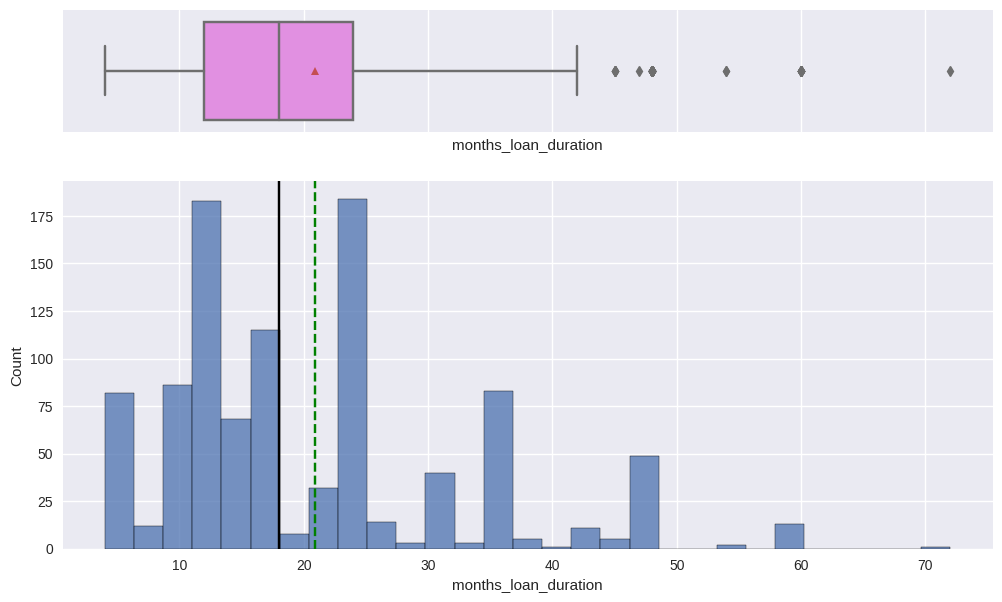

In [ ]:
# Distribution of months_loan_duration
histogram_boxplot(data,'months_loan_duration')

* From the boxplot we can observe the presence of outliers
* The distribution of months_loan_duration is positively skewed.
* From the histogram we can understand that most of the customers are between the 1st and 2nd year of taking a loan.



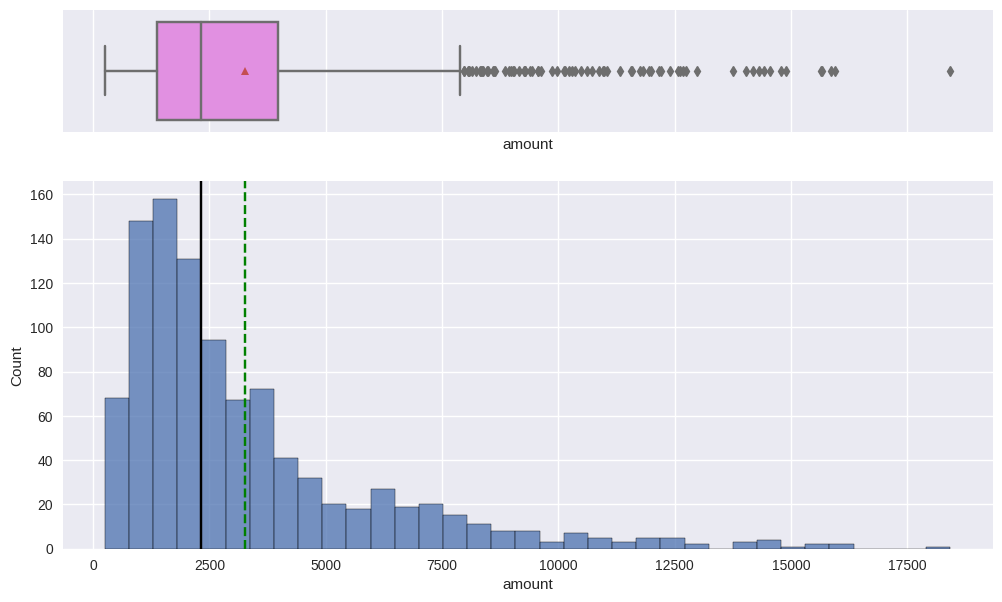

In [ ]:
# Distribution of amount
histogram_boxplot(data,'amount')

* From the boxplot we can observe the presence of outliers
* The distribution of amount is positively skewed.
* From the histogram we can see that most customers taken loans less than 3500. 

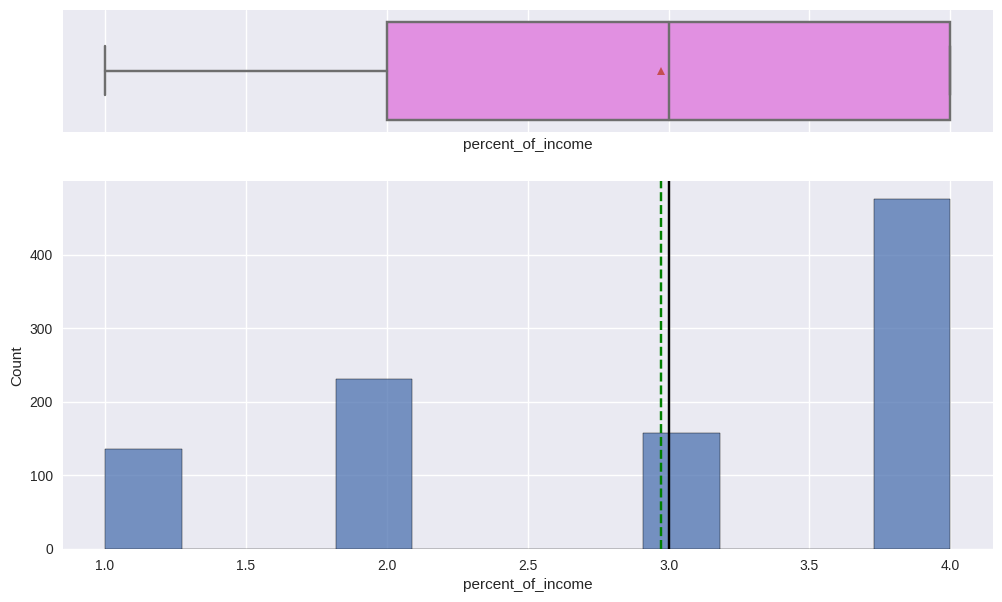

In [ ]:
# Distribution of percent_of_income
histogram_boxplot(data,'percent_of_income')

* From the boxplot we can observe there are no outliers
* The distribution of percent_of_income is not normal.
* From the histogram we can see that most customers are in 4% of their monthly income.

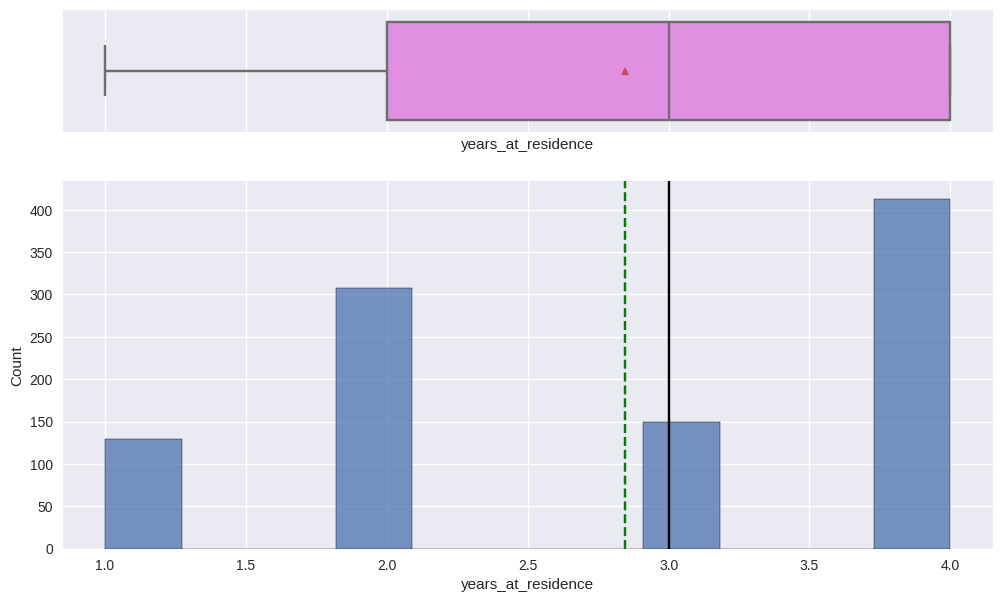

In [ ]:
# Distribution of years_at_residence
histogram_boxplot(data,'years_at_residence')

* From the boxplot we can observe there are no outliers
* The distribution of years_at_residence is not normal.
* From the histogram we can see that most customers are in their current residence for 4 years or more

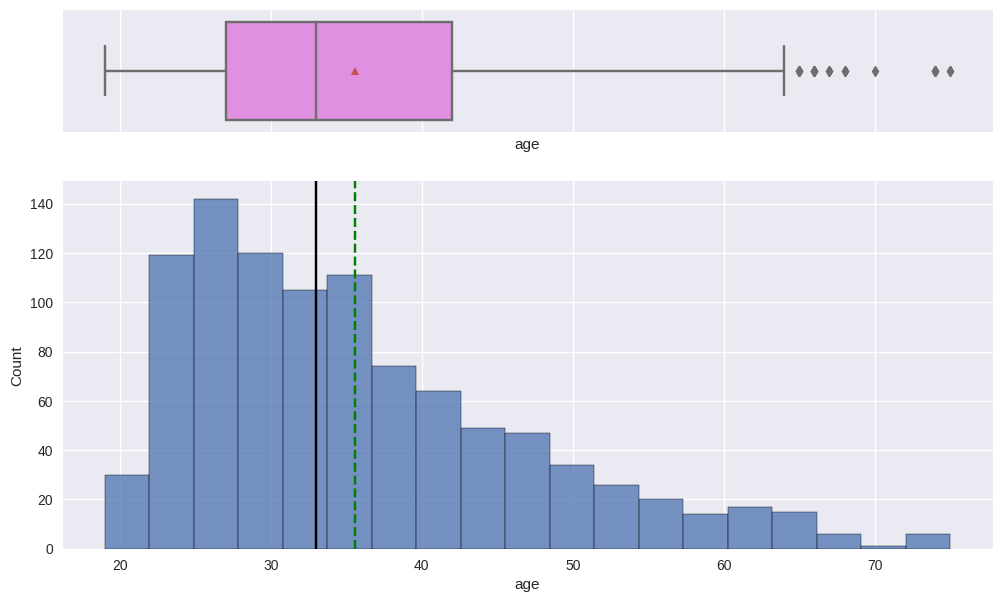

In [ ]:
# Distribution of age
histogram_boxplot(data,'age')

* From the boxplot we can observe there are few outliers
* The distribution of age is positively skewed.
* From the histogram we can see that most customers are less of 40 years of age

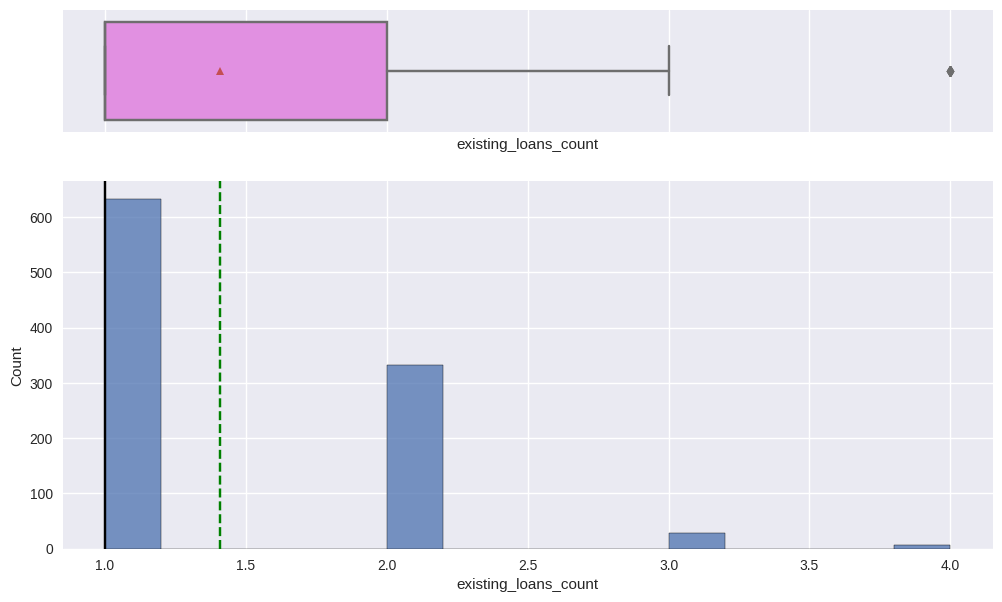

In [ ]:
# Distribution of existing_loans_count
histogram_boxplot(data,'existing_loans_count')

* From the boxplot we can observe there are very less outliers
* The distribution of existing_loans_count is positively skewed.
* From the histogram we can see that most customers have just 1 loan

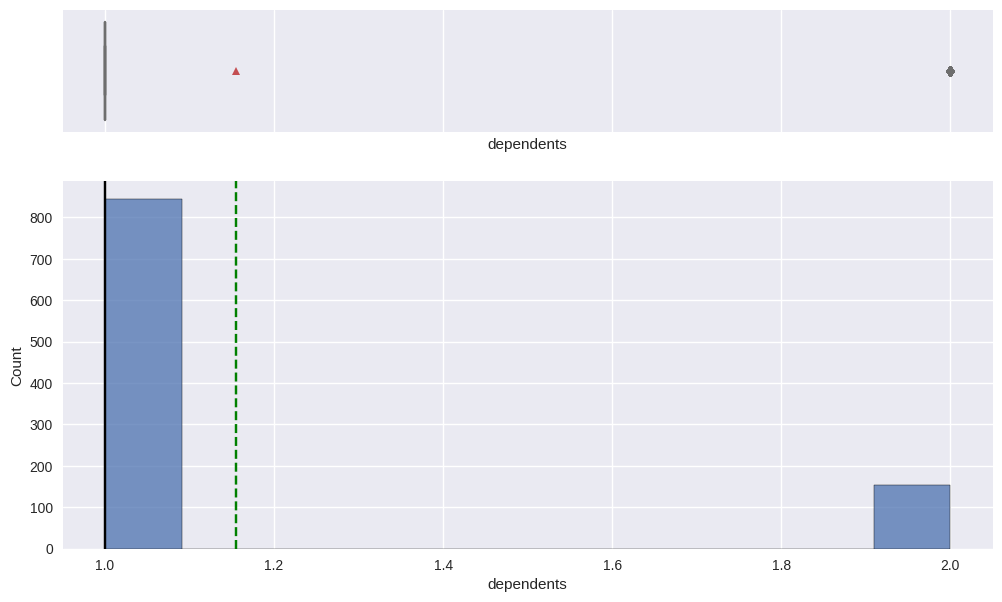

In [ ]:
# Distribution of dependents
histogram_boxplot(data,'dependents')

* Since there are only two values present in the colums, the value with least count is shown as outlier. We can ignore it.
* From the histogram we can see that more than 80% of the customers have only 1 dependent

**Treat outliers in the dataset**

In [ ]:
# Let's treat the outliers in the data by flooring and capping them 0th or 99th percentile
for col in num_cols:
    percentiles = data[col].quantile([0.01, 0.99]).values
    data[col][data[col] <= percentiles[0]] = percentiles[0]
    data[col][data[col] >= percentiles[1]] = percentiles[1]

**Let's define a function to create barplots for the categorical variables indicating percentage of each category for that variables.**

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=10)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=10,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**Observations on checking_balance**

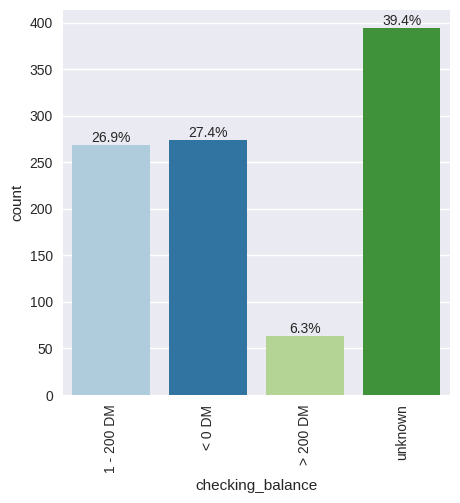

In [ ]:
labeled_barplot(data, "checking_balance", perc=True)

* About 39% of the customers account balance is unknown
* 27.4% of the customer have negative balance in their account

**Observations on credit_history**

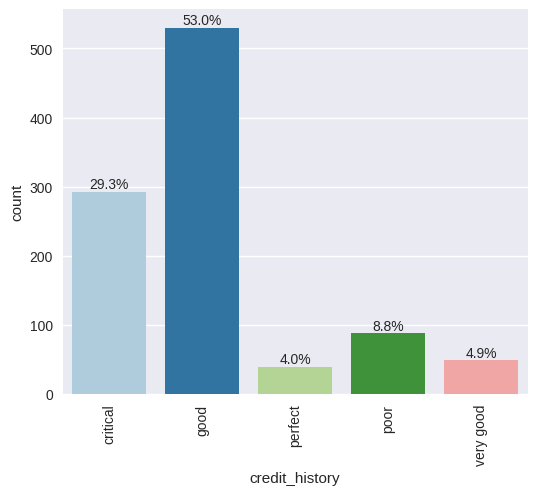

In [ ]:
labeled_barplot(data, "credit_history", perc=True)

* 61.9% of the customers either have good, very good or perfect credit history.
* 38.1% of the customers have critical or poor credit history

**Observations on purpose**

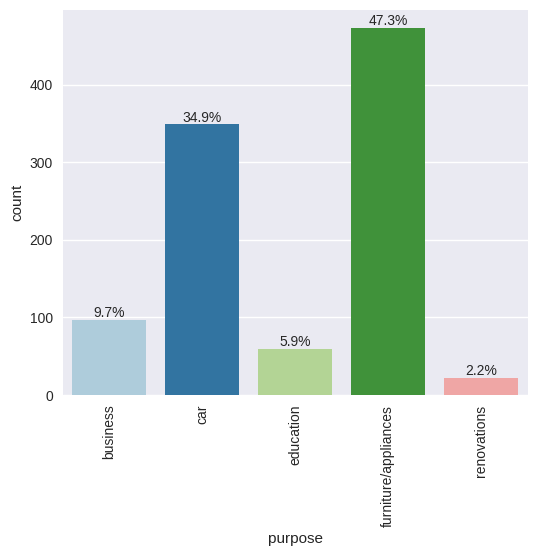

In [ ]:
labeled_barplot(data, "purpose", perc=True)

* 47.3% of the customers have taken loan for buying furniture and appliances
* 33.7% have taken loan for buying a car

**Observations on savings_balance**

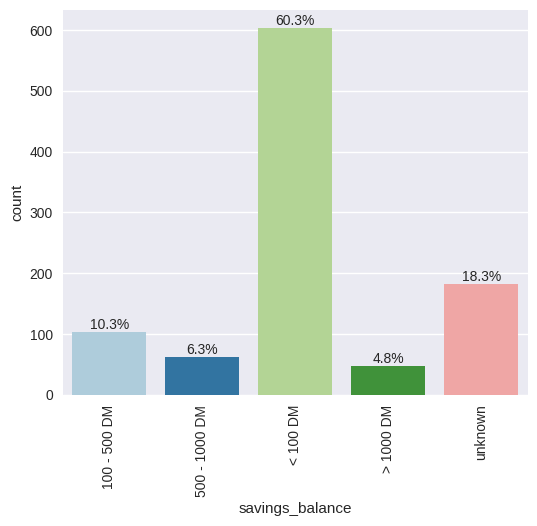

In [ ]:
labeled_barplot(data, "savings_balance", perc=True)

* 60.3% of the customers have savings_balance less than 100 DM

**Observations on employment_duration**

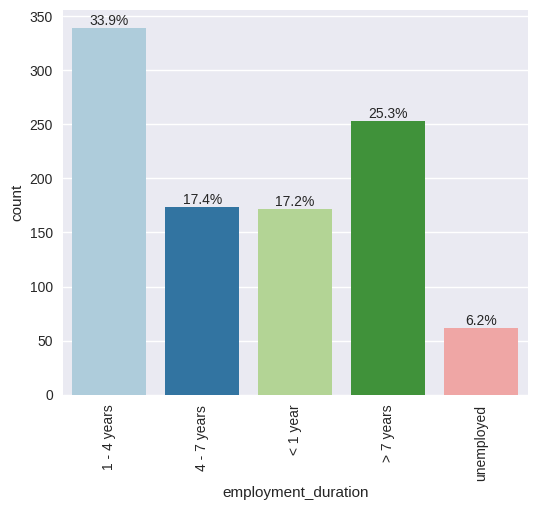

In [ ]:
labeled_barplot(data, "employment_duration", perc=True)

* 51.1% of the customers have employment_duration of less than 4 years.
* 6.2% are unemployed.

**Observations on other_credit**

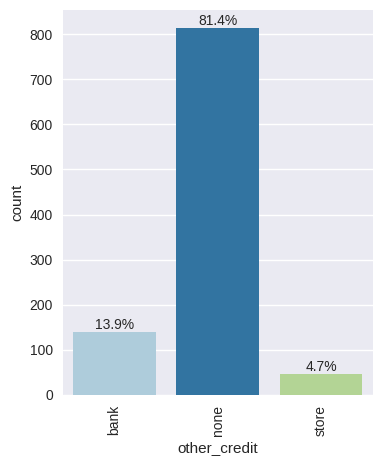

In [ ]:
labeled_barplot(data, "other_credit", perc=True)

* 81.4% of the customers have not taken any other credits.

**Observations on housing**

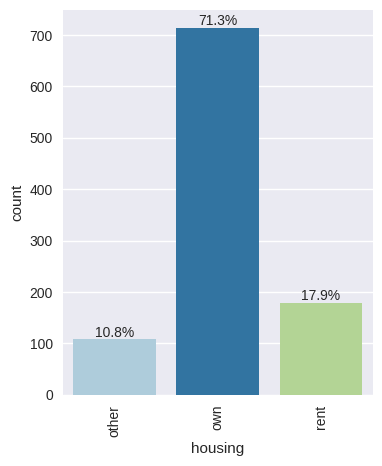

In [ ]:
labeled_barplot(data, "housing", perc=True)

* 71.3% of the customers have own house/appartment.

**Observations on job**

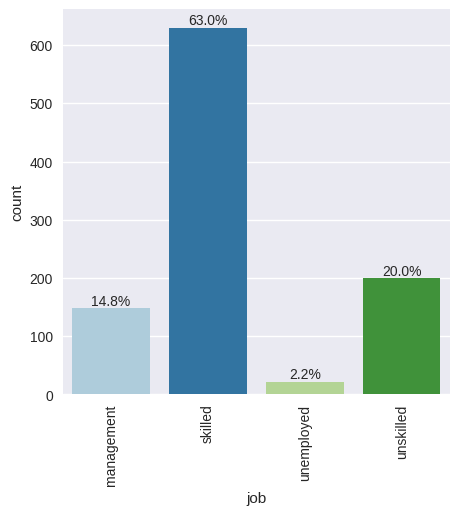

In [ ]:
labeled_barplot(data, "job", perc=True)

* 63% of the customers job type is skilled.

**Observations on phone**

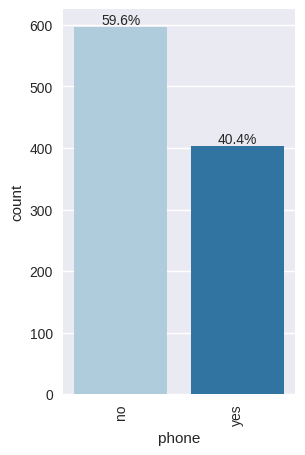

In [ ]:
labeled_barplot(data, "phone", perc=True)

* 59.6% of the customers do not have a phone

**Observations on default**

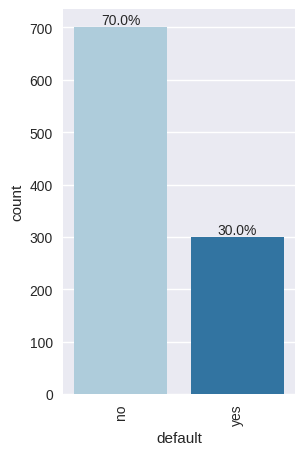

In [ ]:
labeled_barplot(data, "default", perc=True)

* 30% of the customers are default.

### **Bivariate Analysis**

**Let's find out the relationship between default and other columns**

**Months Loan Duration vs Default**

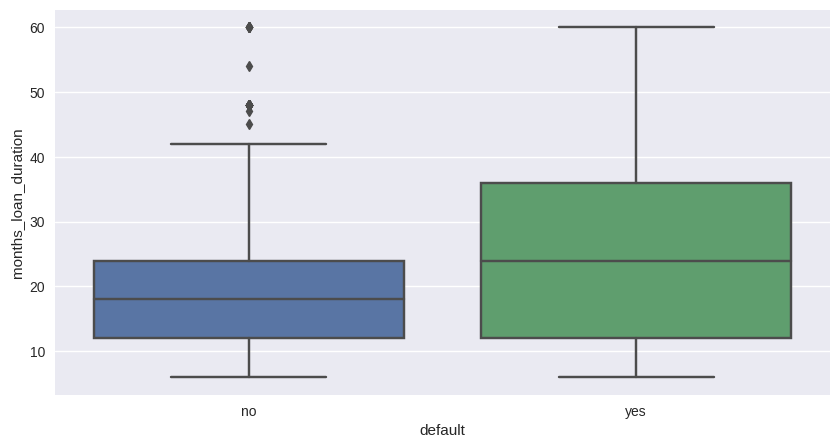

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(y='months_loan_duration',x='default',data=data)
plt.show()

- The spread of 'yes' is greater than 'no'. This implies that borrowers who have loans for longer periods of time are more likely to default.

**Amount vs Default**

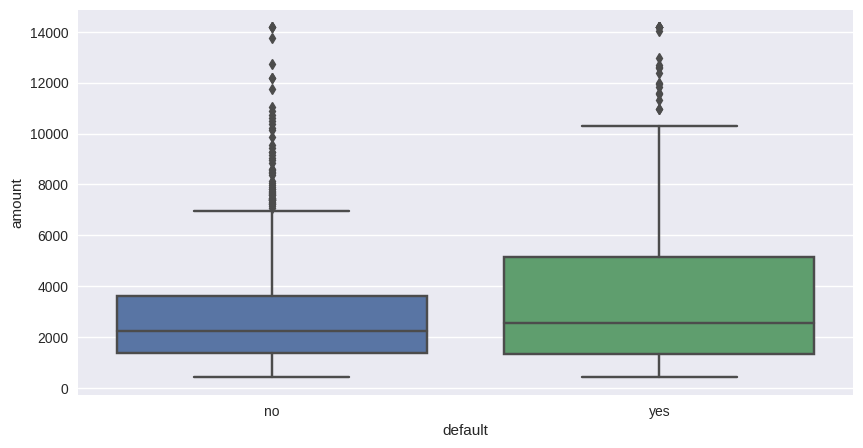

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(y='amount',x='default',data=data)
plt.show()

- Customers with higher loan amount are more likely to default.

**Age vs Default**

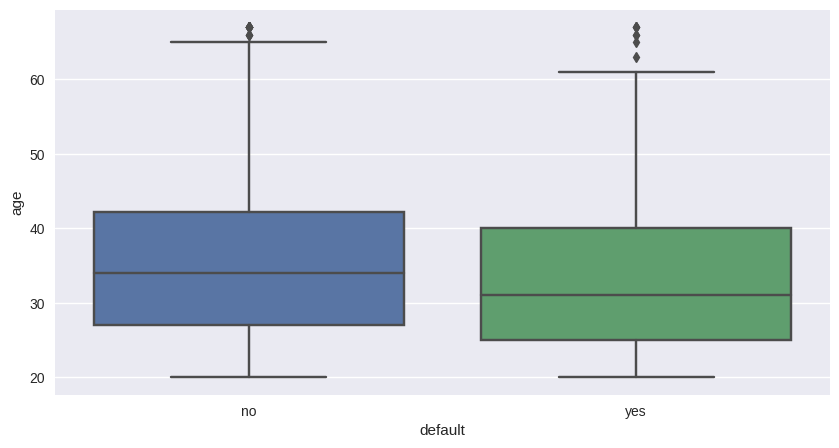

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(y='age',x='default',data=data)
plt.show()

- Customers who are younger have a higher default rate.

**Let's define one more function to plot stacked bar charts**

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

**Default vs Credit History**

default          no  yes   All
credit_history                
All             700  300  1000
good            361  169   530
critical        243   50   293
poor             60   28    88
very good        21   28    49
perfect          15   25    40
------------------------------------------------------------------------------------------------------------------------


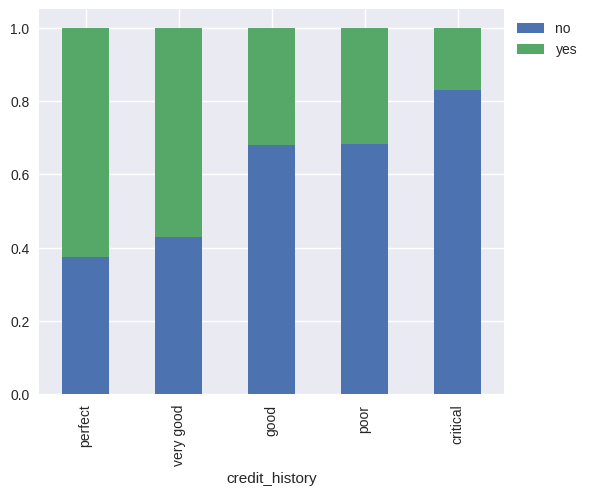

In [ ]:
stacked_barplot(data, "credit_history", "default" )

* More than 60% of the customers who have perfect credit history have become defaulters. Surprisingly, people with better history are becoming more default than the ones with critical and poor credit history

**Purpose vs Default**

default                no  yes   All
purpose                             
All                   700  300  1000
furniture/appliances  349  124   473
car                   238  111   349
business               63   34    97
education              36   23    59
renovations            14    8    22
------------------------------------------------------------------------------------------------------------------------


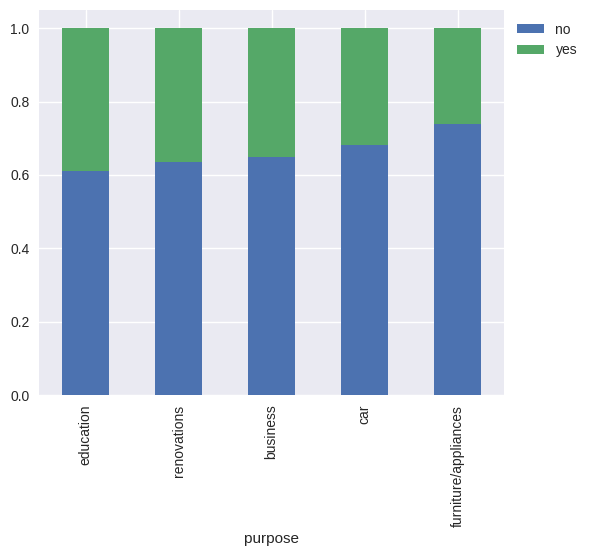

In [ ]:
stacked_barplot(data, "purpose", "default" )

* 40% of the customers who have taken loan for education have become defaulters.

**Employment Duration vs Default**

default               no  yes   All
employment_duration                
All                  700  300  1000
1 - 4 years          235  104   339
< 1 year             102   70   172
> 7 years            189   64   253
4 - 7 years          135   39   174
unemployed            39   23    62
------------------------------------------------------------------------------------------------------------------------


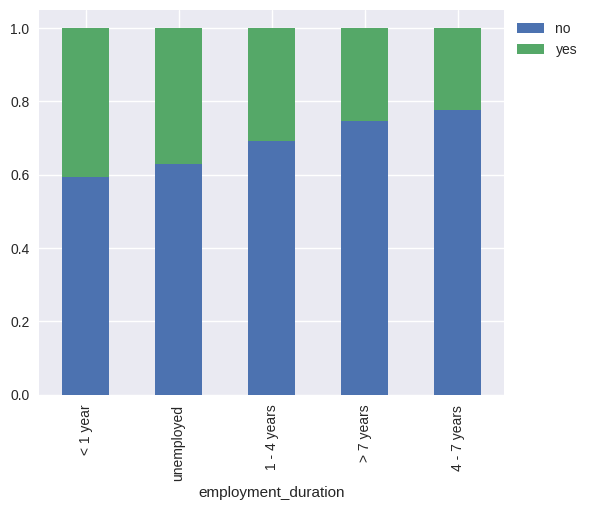

In [ ]:
stacked_barplot(data, "employment_duration", "default" )

* About 40% of the customers who have less than 1 year of employement have become defaulters.

**Percent of Income vs Default**

default             no  yes   All
percent_of_income                
All                700  300  1000
4                  317  159   476
2                  169   62   231
3                  112   45   157
1                  102   34   136
------------------------------------------------------------------------------------------------------------------------


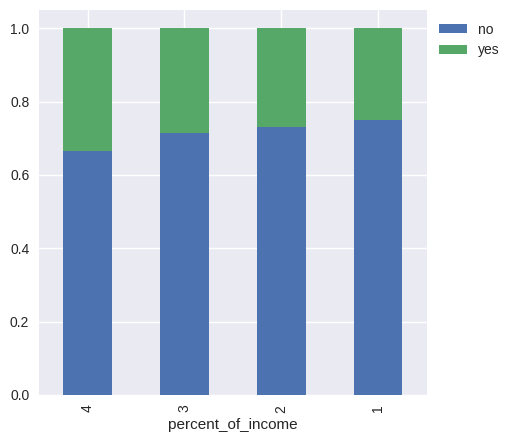

In [ ]:
stacked_barplot(data, "percent_of_income", "default" )

* Close to 35% of customers who have an income percentage of 4 have defaulted.

**Years At Residence vs Default**

default              no  yes   All
years_at_residence                
All                 700  300  1000
4                   289  124   413
2                   211   97   308
3                   106   43   149
1                    94   36   130
------------------------------------------------------------------------------------------------------------------------


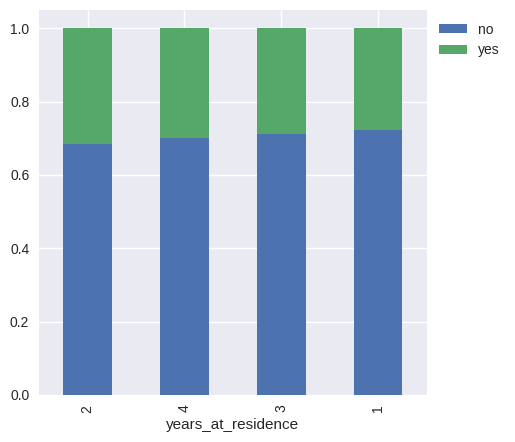

In [ ]:
stacked_barplot(data, "years_at_residence", "default" )

* Years at residence does not show much difference in the defaulters spread

**Other Credit vs Default**

default        no  yes   All
other_credit                
All           700  300  1000
none          590  224   814
bank           82   57   139
store          28   19    47
------------------------------------------------------------------------------------------------------------------------


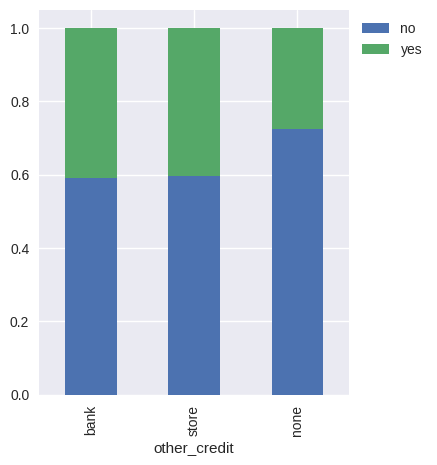

In [ ]:
stacked_barplot(data, "other_credit", "default" )

* About 40% of the customers who have other credits at bank or store have become default

**Housing vs Default**

default   no  yes   All
housing                
All      700  300  1000
own      527  186   713
rent     109   70   179
other     64   44   108
------------------------------------------------------------------------------------------------------------------------


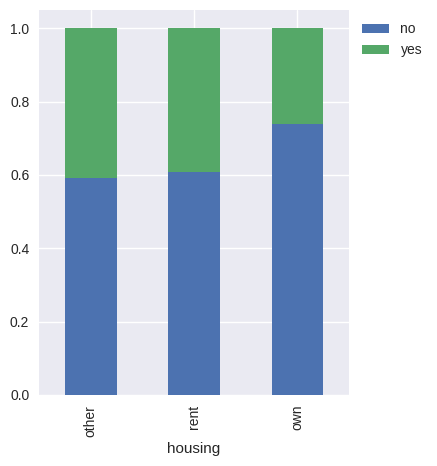

In [ ]:
stacked_barplot(data, "housing", "default" )

* About 40% of the customers who have other and rent housing type have become default

**Existing Loans Count vs Default**

default                no  yes   All
existing_loans_count                
All                   700  300  1000
1                     433  200   633
2                     241   92   333
3                      26    8    34
------------------------------------------------------------------------------------------------------------------------


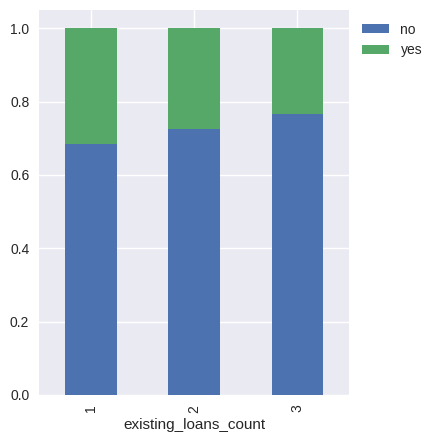

In [ ]:
stacked_barplot(data, "existing_loans_count", "default" )

* Close to 33% of customers who have an existing loan count of 4 have defaulted.

**Job Type vs Default**

default      no  yes   All
job                       
All         700  300  1000
skilled     444  186   630
unskilled   144   56   200
management   97   51   148
unemployed   15    7    22
------------------------------------------------------------------------------------------------------------------------


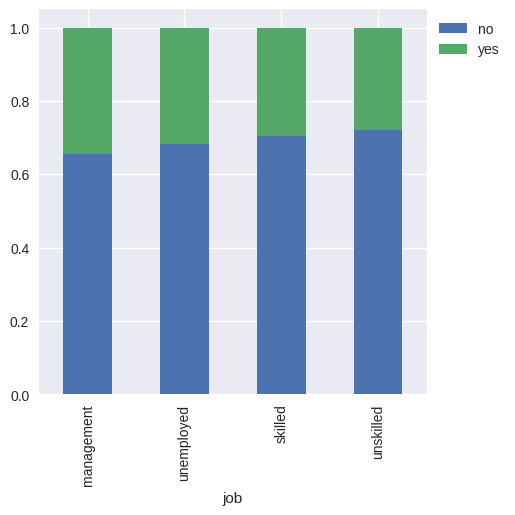

In [ ]:
stacked_barplot(data, "job", "default" )

* We can observe slight variations in default proproption in job type

**Dependents vs Default**

default      no  yes   All
dependents                
All         700  300  1000
1           591  254   845
2           109   46   155
------------------------------------------------------------------------------------------------------------------------


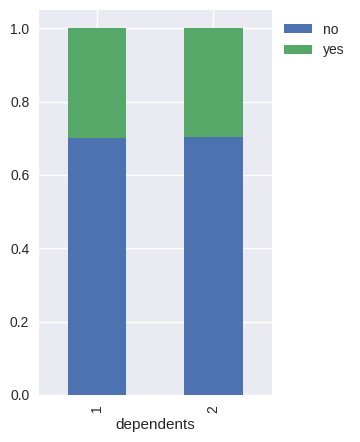

In [ ]:
stacked_barplot(data, "dependents", "default" )

* Dependents do not have any impact on the default status

**Phone vs Default**

default   no  yes   All
phone                  
All      700  300  1000
no       409  187   596
yes      291  113   404
------------------------------------------------------------------------------------------------------------------------


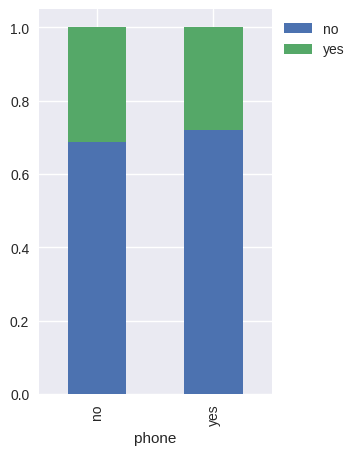

In [ ]:
stacked_barplot(data, "phone", "default" )

* There is only slight variation in between phone and default

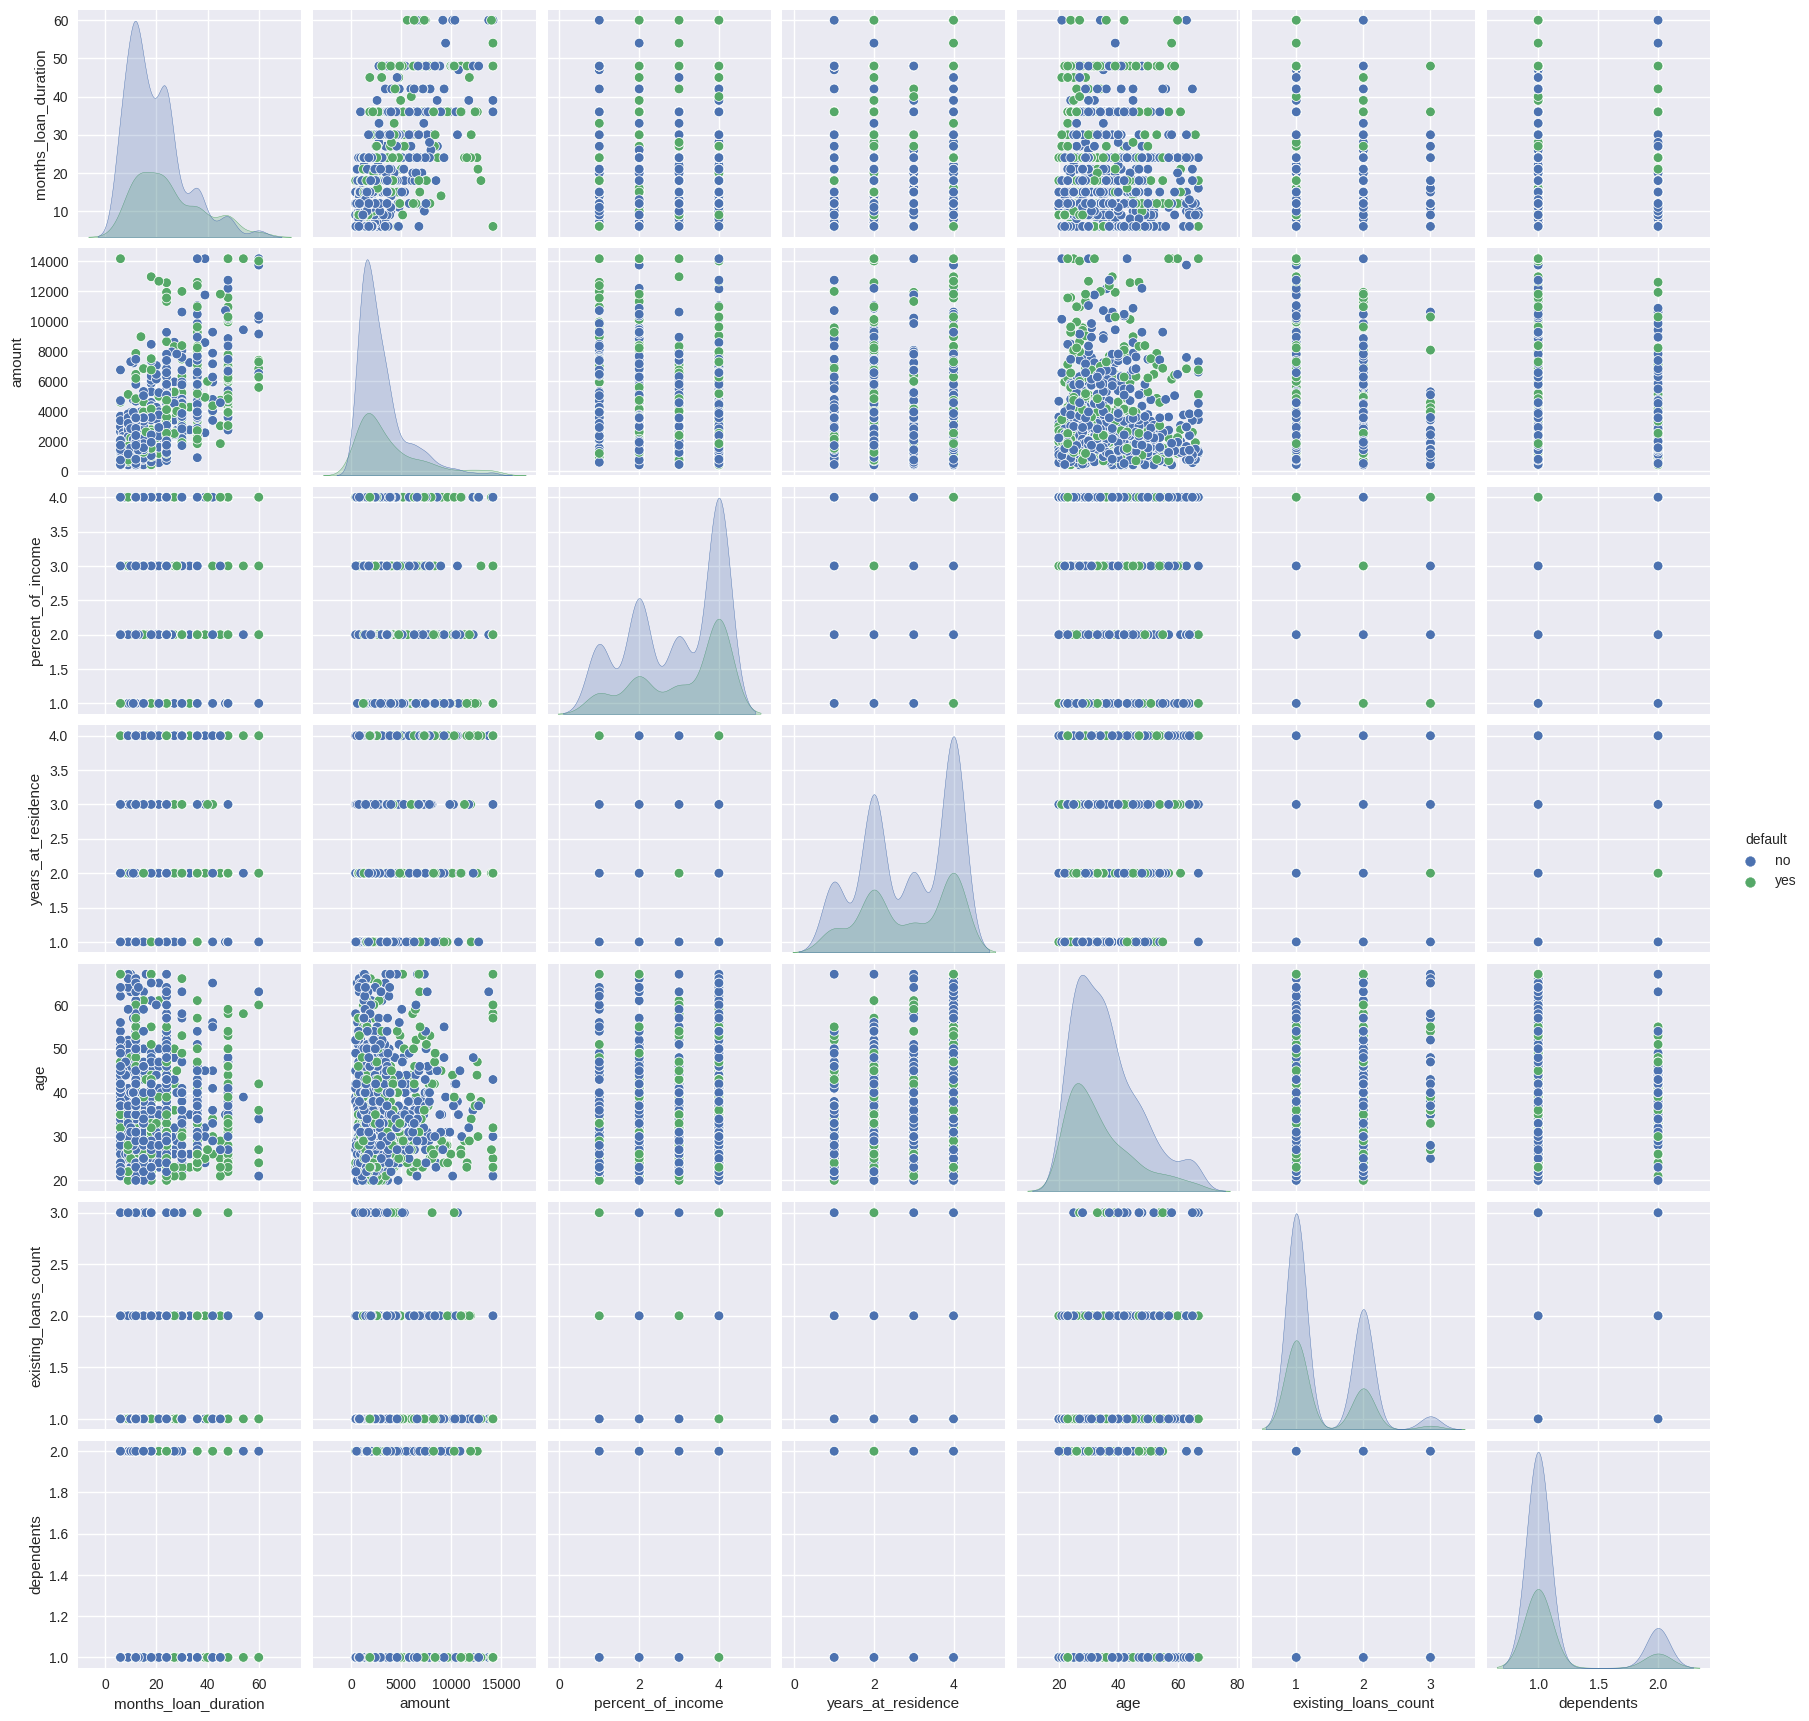

In [ ]:
sns.pairplot(data=data,hue='default')

* From the diagonal distribution plot we can see that defaulters and non-defaulters have same distribution in all the variables
* Most people with less age and more months_loan_duration are found to be defaulters

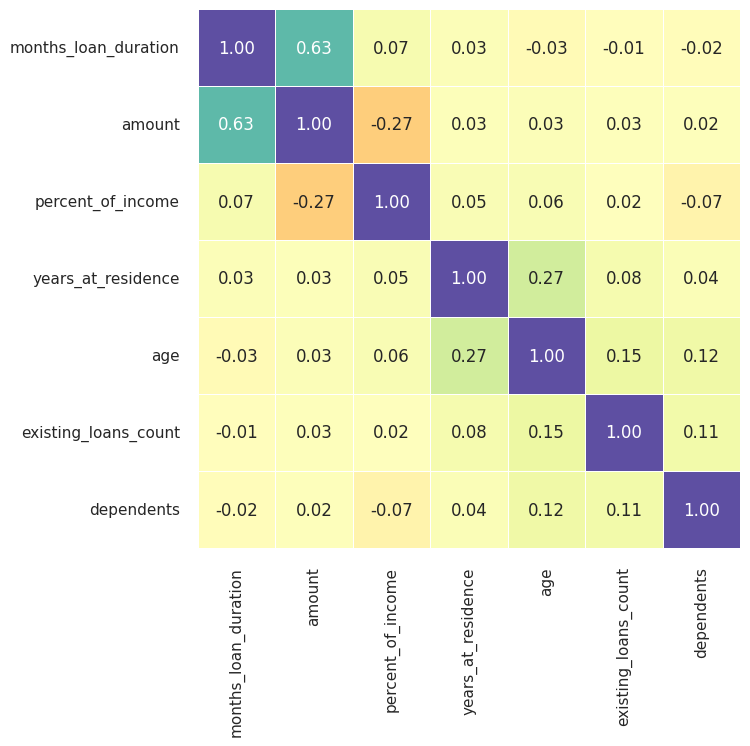

In [ ]:
sns.set(rc={'figure.figsize':(7,7)})
sns.heatmap(data.corr(),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap="Spectral",
            fmt='0.2f')
plt.show()

* Amount and months_loan_duration are positively correlated
* Age and years_at_residence have weak positive correlation
* Rest of the variables are not correlated

### **Split the dataset into train and test sets**

In [ ]:
# Splitting the data into 70% train and 30% test sets
X_train, X_test,y_train,y_test = train_test_split(data.drop(columns='default'),data['default'],random_state=67,test_size=.3)

**Let's do ordinal encoding and create dummies for categorical variables**

In [ ]:
transformer = ColumnTransformer(transformers= [
    ('tf1', OrdinalEncoder(categories=[["unknown","< 0 DM","1 - 200 DM","> 200 DM"]]),["checking_balance"]),
    ('tf2', OrdinalEncoder(categories=[["critical","poor","good","very good","perfect"]]),["credit_history"]),
    ('tf3', OrdinalEncoder(categories=[["unknown","< 100 DM","100 - 500 DM","500 - 1000 DM","> 1000 DM"]]),["savings_balance"]),
    ('tf4', OrdinalEncoder(categories=[["unemployed","< 1 year","1 - 4 years","4 - 7 years","> 7 years"]]),["employment_duration"]),
    ('tf5', OneHotEncoder(sparse = False, drop = 'first'),['purpose','housing','job','phone','other_credit'])
], remainder = 'passthrough')
transformer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('tf1',
                                 OrdinalEncoder(categories=[['unknown',
                                                             '< 0 DM',
                                                             '1 - 200 DM',
                                                             '> 200 DM']]),
                                 ['checking_balance']),
                                ('tf2',
                                 OrdinalEncoder(categories=[['critical', 'poor',
                                                             'good',
                                                             'very good',
                                                             'perfect']]),
                                 ['credit_history']),
                                ('tf3',
                                 OrdinalEncoder(categories=[['unknown',
                                                             '< 100 DM',
                                                             '100 - 500 DM',
                                                             '500 - 1000 DM',
                                                             '> 1000 DM']]),
                                 ['savings_balance']),
                                ('tf4',
                                 OrdinalEncoder(categories=[['unemployed',
                                                             '< 1 year',
                                                             '1 - 4 years',
                                                             '4 - 7 years',
                                                             '> 7 years']]),
                                 ['employment_duration']),
                                ('tf5',
                                 OneHotEncoder(drop='first', sparse=False),
                                 ['purpose', 'housing', 'job', 'phone',
                                  'other_credit'])])

In [ ]:
X_train = transformer.fit_transform(X_train)

In [ ]:
X_test = transformer.transform(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(700, 23)
(300, 23)


- `years_at_residence`, `existing_loans_count`,`dependents` are categorical variables but has numeric datatype. Since the categories are in 1,2,3,4, etc. We need not label encode them separately.

### **Building the Model**

Let's build different machine learning and tree based models to predict whether the customer will default or not based on historical data.

**Let's create a function to print different classification metrics**

In [ ]:
def classify(classifier):
    classifier.fit(X_train,y_train)
    train_pred = classifier.predict(X_train)
    test_pred = classifier.predict(X_test)
    print("Train Accuracy is: ",accuracy_score(y_train,train_pred))
    print('*'*20)
    print("Test Accuracy is: ",accuracy_score(y_test,test_pred))
    print('*'*20)
    print("Training metrics: \n",classification_report(y_train,train_pred))
    print('*'*20)
    print("Testing metrics: \n",classification_report(y_test,test_pred))
    print('*'*20)

**Let's create a function to calculate confusion matrix, so that we don't have to use the same code repeatedly for each model**

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    xy_labels = np.unique(y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=labels, fmt="",xticklabels= xy_labels, yticklabels=xy_labels)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### **Logistic Regression**

In [ ]:
# Fitting the logistic regression model
lg = LogisticRegression()

lg.fit(X_train,y_train)

LogisticRegression()

In [ ]:
# Checking the performance
classify(lg)


Train Accuracy is:  0.7257142857142858
********************
Test Accuracy is:  0.7033333333333334
********************
Training metrics: 
               precision    recall  f1-score   support

          no       0.74      0.93      0.83       494
         yes       0.59      0.23      0.33       206

    accuracy                           0.73       700
   macro avg       0.67      0.58      0.58       700
weighted avg       0.70      0.73      0.68       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.72      0.94      0.81       206
         yes       0.59      0.18      0.28        94

    accuracy                           0.70       300
   macro avg       0.65      0.56      0.54       300
weighted avg       0.68      0.70      0.65       300

********************


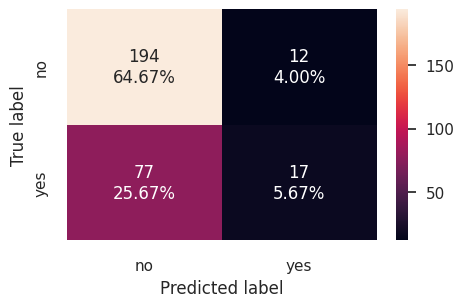

In [ ]:
confusion_matrix_sklearn(lg,X_test,y_test)

- The reported average includes the macro average which averages the unweighted mean per label, and the weighted average which averages the support-weighted mean per label.
- In classification, the class of interest is 'yes', i.e., identifying the customers who would default.

**Reading the confusion matrix (clockwise from top left):**

* True Negative (Actual = no, Predicted = no): Model predicts that the customer would not default and the customer is non-default

* False Positive (Actual = no, Predicted = yes): Model predicts that the customer would default and the customer is non-default

* True Positive (Actual = yes, Predicted = yes): Model predicts that the customer would default and the customer is default

* False Negative (Actual = yes, Predicted = no): Model predicts that the customer would not default and the customer is default

**Observations:**

- The recall for class 'yes' is quite low, which implies that this model will not perform well in differentiating the customers who have a high chance of becoming default, and hence this model would not help in identifying the detault customers.

In [ ]:
knn = KNeighborsClassifier()
classify(knn)

Train Accuracy is:  0.7528571428571429
********************
Test Accuracy is:  0.6833333333333333
********************
Training metrics: 
               precision    recall  f1-score   support

          no       0.78      0.91      0.84       494
         yes       0.64      0.36      0.46       206

    accuracy                           0.75       700
   macro avg       0.71      0.64      0.65       700
weighted avg       0.74      0.75      0.73       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.71      0.90      0.80       206
         yes       0.49      0.20      0.29        94

    accuracy                           0.68       300
   macro avg       0.60      0.55      0.54       300
weighted avg       0.64      0.68      0.64       300

********************


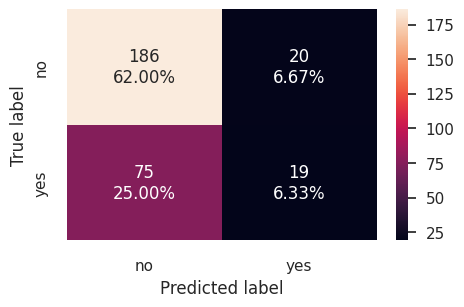

In [ ]:
confusion_matrix_sklearn(knn,X_test,y_test)

* **The base model is providing train and test accuracy of 75% and 68%. Let's try to tune the model and check if the performance can be improved.**

In [ ]:
knn_1 = KNeighborsClassifier(n_neighbors=10,algorithm='auto',weights='distance',p=2)
classify(knn_1)

Train Accuracy is:  1.0
********************
Test Accuracy is:  0.6933333333333334
********************
Training metrics: 
               precision    recall  f1-score   support

          no       1.00      1.00      1.00       494
         yes       1.00      1.00      1.00       206

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.71      0.94      0.81       206
         yes       0.54      0.16      0.25        94

    accuracy                           0.69       300
   macro avg       0.62      0.55      0.53       300
weighted avg       0.66      0.69      0.63       300

********************


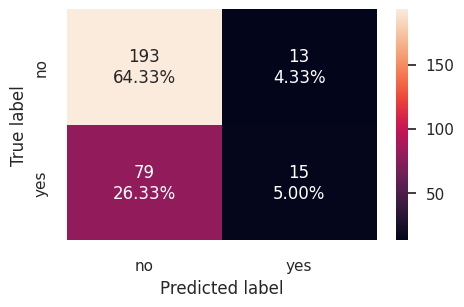

In [ ]:
confusion_matrix_sklearn(knn_1,X_test,y_test)

* **Both train and test performances were improved. But the model is overfitting on the training data and the test recall for 'yes' is low**

### **Decision Tree Classifier**




In [ ]:
#Fitting the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train,y_train)

#Calculating different metrics
classify(d_tree)

Train Accuracy is:  1.0
********************
Test Accuracy is:  0.6766666666666666
********************
Training metrics: 
               precision    recall  f1-score   support

          no       1.00      1.00      1.00       494
         yes       1.00      1.00      1.00       206

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.76      0.78      0.77       206
         yes       0.48      0.45      0.46        94

    accuracy                           0.68       300
   macro avg       0.62      0.61      0.62       300
weighted avg       0.67      0.68      0.67       300

********************


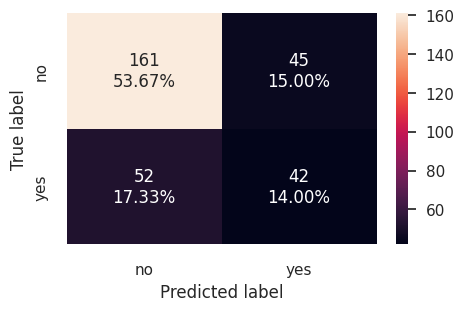

In [ ]:
confusion_matrix_sklearn(d_tree,X_test,y_test)

- Decision Tree model has a train and test accuracy of 100% and 68%
- It is very overfitting on the train set as there is a 32% variation in the train and test accuracy

## **Random Forest Classifier**

Train Accuracy is:  1.0
********************
Test Accuracy is:  0.76
********************
Training metrics: 
               precision    recall  f1-score   support

          no       1.00      1.00      1.00       494
         yes       1.00      1.00      1.00       206

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.77      0.94      0.84       206
         yes       0.73      0.37      0.49        94

    accuracy                           0.76       300
   macro avg       0.75      0.65      0.67       300
weighted avg       0.75      0.76      0.73       300

********************


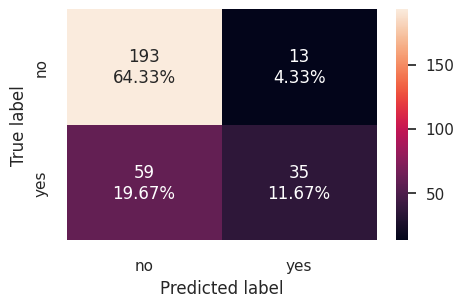

In [ ]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
classify(rf_estimator)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

- Random Forest model has a train and test accuracy of 100% and 76%
- It is very overfitting on the train set as there is a 24% variation in the train and test accuracy
- The recall of test class .37 which makes the model unreliable

**Let's tune the hyperparameters to see if we can improve the accuracy better.**

Train Accuracy is:  0.7714285714285715
********************
Test Accuracy is:  0.67
********************
Training metrics: 
               precision    recall  f1-score   support

          no       0.90      0.76      0.82       494
         yes       0.58      0.81      0.67       206

    accuracy                           0.77       700
   macro avg       0.74      0.78      0.75       700
weighted avg       0.81      0.77      0.78       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.82      0.67      0.74       206
         yes       0.48      0.67      0.56        94

    accuracy                           0.67       300
   macro avg       0.65      0.67      0.65       300
weighted avg       0.71      0.67      0.68       300

********************


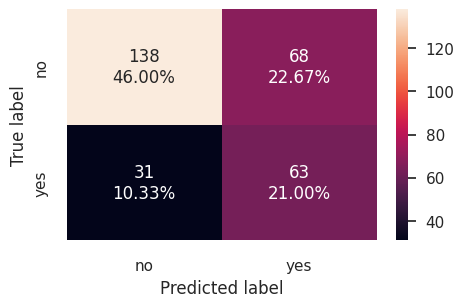

In [ ]:
# Assign class_weight according to the target class. 
rf_tuned = RandomForestClassifier(class_weight={'no':0.30,'yes':0.7},random_state=1,oob_score=True,bootstrap=True)

parameters = {  
                'max_depth': list(np.arange(5,30,5)) + [None],
                'max_features': ['sqrt','log2',None],
                'min_samples_leaf': np.arange(1,15,5),
                'min_samples_split': np.arange(2, 20, 5),
                'n_estimators': np.arange(10,110,10)}


# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring='recall',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
rf_tuned.fit(X_train, y_train)

#Calculating different metrics
classify(rf_tuned)

#Creating confusion matrix
confusion_matrix_sklearn(rf_tuned,X_test,y_test)

- Tuned Random Forest model has a decent train and test accuracy of 77% and 67%
- It is very slighting overfitting on the train set since the accuracy of train is slightly better than test
- The recall of test class .67 which is better compared to other previous models

## **Bagging Classifier**

Train Accuracy is:  0.9871428571428571
********************
Test Accuracy is:  0.76
********************
Training metrics: 
               precision    recall  f1-score   support

          no       0.98      1.00      0.99       494
         yes       0.99      0.96      0.98       206

    accuracy                           0.99       700
   macro avg       0.99      0.98      0.98       700
weighted avg       0.99      0.99      0.99       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.78      0.91      0.84       206
         yes       0.69      0.43      0.53        94

    accuracy                           0.76       300
   macro avg       0.73      0.67      0.68       300
weighted avg       0.75      0.76      0.74       300

********************


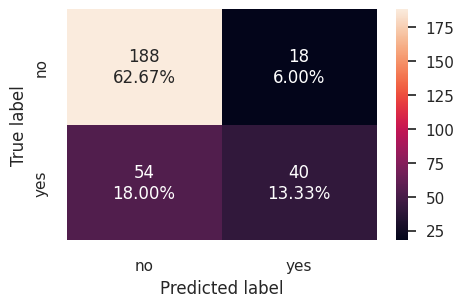

In [ ]:
#Fitting the model
bag = BaggingClassifier(random_state=1)
bag.fit(X_train,y_train)

#Calculating different metrics
classify(bag)

#Creating confusion matrix
confusion_matrix_sklearn(bag,X_test,y_test)

The train and test accuracies of Bagging model are 98% and 76% which makes it a overfit model. Also, the recall value for the test class 'yes' is low.

## **AdaBoost Classifier**

Train Accuracy is:  0.7928571428571428
********************
Test Accuracy is:  0.7566666666666667
********************
Training metrics: 
               precision    recall  f1-score   support

          no       0.81      0.93      0.86       494
         yes       0.73      0.47      0.57       206

    accuracy                           0.79       700
   macro avg       0.77      0.70      0.72       700
weighted avg       0.78      0.79      0.78       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.79      0.88      0.83       206
         yes       0.65      0.49      0.56        94

    accuracy                           0.76       300
   macro avg       0.72      0.68      0.69       300
weighted avg       0.75      0.76      0.75       300

********************


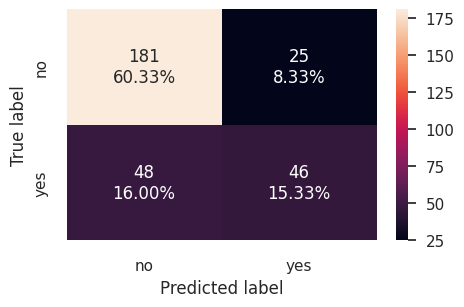

In [ ]:
#Fitting the model
abc = AdaBoostClassifier(random_state=1)
abc.fit(X_train,y_train)

#Calculating different metrics
classify(abc)

#Creating confusion matrix
confusion_matrix_sklearn(abc,X_test,y_test)

- Ada Boost has a decent train and test accuracy of 79% and 75%
- It is not overfitting since the accuracy of test and train are similar
- The recall of test class 'yes' is low (.49)

## **Gradient Boosting Classifier**

Train Accuracy is:  0.8971428571428571
********************
Test Accuracy is:  0.74
********************
Training metrics: 
               precision    recall  f1-score   support

          no       0.88      0.99      0.93       494
         yes       0.95      0.68      0.80       206

    accuracy                           0.90       700
   macro avg       0.92      0.84      0.86       700
weighted avg       0.90      0.90      0.89       700

********************
Testing metrics: 
               precision    recall  f1-score   support

          no       0.76      0.90      0.83       206
         yes       0.64      0.38      0.48        94

    accuracy                           0.74       300
   macro avg       0.70      0.64      0.65       300
weighted avg       0.72      0.74      0.72       300

********************


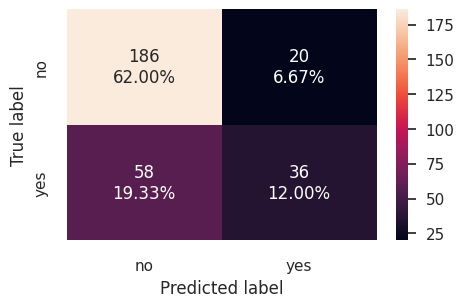

In [ ]:
#Fitting the model
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(X_train,y_train)

#Calculating different metrics
classify(gbc)

#Creating confusion matrix
confusion_matrix_sklearn(gbc,X_test,y_test)

- Gradient Boosting has a decent train and test accuracy of 89% and 74%
- It is slightly overfitting on the train set as the accuracy of train set is slightly greater
- The recall of test class 'yes' is low (.38) making it not a best model

## **Comparing all models**

**Roc Curve**

In [ ]:
# predict probabilities
pred_prob1 = lg.predict_proba(X_test)
pred_prob2 = knn.predict_proba(X_test)
pred_prob3 = knn_1.predict_proba(X_test)
pred_prob4 = d_tree.predict_proba(X_test)
pred_prob5 = rf_estimator.predict_proba(X_test)
pred_prob6 = rf_tuned.predict_proba(X_test)
pred_prob7 = bag.predict_proba(X_test)
pred_prob8 = abc.predict_proba(X_test)
pred_prob9 = gbc.predict_proba(X_test)


# roc curve for models
fpr1, tpr1, thresh1 = roc_curve(y_test, pred_prob1[:,1], pos_label='yes')
fpr2, tpr2, thresh2 = roc_curve(y_test, pred_prob2[:,1], pos_label='yes')
fpr3, tpr3, thresh3 = roc_curve(y_test, pred_prob3[:,1], pos_label='yes')
fpr4, tpr4, thresh4 = roc_curve(y_test, pred_prob4[:,1], pos_label='yes')
fpr5, tpr5, thresh5 = roc_curve(y_test, pred_prob5[:,1], pos_label='yes')
fpr6, tpr6, thresh6 = roc_curve(y_test, pred_prob6[:,1], pos_label='yes')
fpr7, tpr7, thresh7 = roc_curve(y_test, pred_prob7[:,1], pos_label='yes')
fpr8, tpr8, thresh8 = roc_curve(y_test, pred_prob8[:,1], pos_label='yes')
fpr9, tpr9, thresh9 = roc_curve(y_test, pred_prob9[:,1], pos_label='yes')

# roc curve for tpr = fpr 
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label='yes')


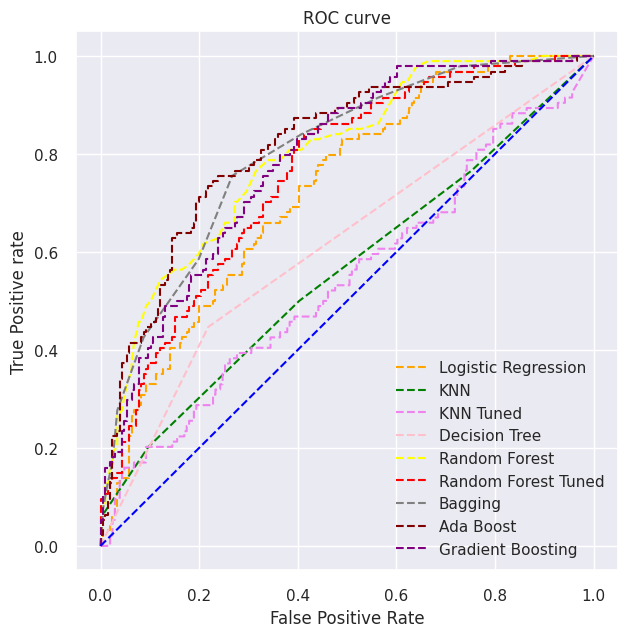

In [ ]:
# plot roc curves
plt.plot(fpr1, tpr1, linestyle='--',color='orange', label='Logistic Regression')
plt.plot(fpr2, tpr2, linestyle='--',color='green', label='KNN')
plt.plot(fpr3, tpr3, linestyle='--',color='violet', label='KNN Tuned')
plt.plot(fpr4, tpr4, linestyle='--',color='pink', label='Decision Tree')
plt.plot(fpr5, tpr5, linestyle='--',color='yellow', label='Random Forest')
plt.plot(fpr6, tpr6, linestyle='--',color='red', label='Random Forest Tuned')
plt.plot(fpr7, tpr7, linestyle='--',color='grey', label='Bagging')
plt.plot(fpr8, tpr8, linestyle='--',color='maroon', label='Ada Boost')
plt.plot(fpr9, tpr9, linestyle='--',color='purple', label='Gradient Boosting')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC',dpi=300)
plt.show();

From the above ROC curve we can see that Ada Boost, Gradient Boosting, Random Forest, Tuned Random Forest and Bagging are providing closer results compared to other models

In [ ]:
# auc scores
Rf_auc = roc_auc_score(y_test, pred_prob5[:,1])
Tuned_Rf_auc = roc_auc_score(y_test, pred_prob6[:,1])
Ada_auc = roc_auc_score(y_test, pred_prob8[:,1])
Grad_auc = roc_auc_score(y_test, pred_prob9[:,1])
Bag_auc = roc_auc_score(y_test, pred_prob7[:,1])

print("Auc Score of Random Forest Model is ", Rf_auc)
print("Auc Score of Tuned Random Forest Model is ", Tuned_Rf_auc)
print("Auc Score of Ada Boost Model is ", Ada_auc)
print("Auc Score of Gradient Boosting Model is ", Grad_auc)
print("Auc Score of Bagging Model is ", Bag_auc)

Auc Score of Random Forest Model is  0.7952902292914688
Auc Score of Tuned Random Forest Model is  0.7588308200784961
Auc Score of Ada Boost Model is  0.8124354472216484
Auc Score of Gradient Boosting Model is  0.7855814914273911
Auc Score of Bagging Model is  0.7993699648832885


From the above AUC scores, we see that Ada Boost model results in slightly higher AUC score.

## **Finding Best Model**

- By comparing all the model's performance metrics, we pick Tuned Random Forest Model as the best model because of the higher test recall value for default = 'yes' (0.67). The objective of the problem is to identify the customer who will default, so that appropriate action can be taken to reduce the default count

## **Feature Importance of the best model**

Text(0.5, 0, 'Feature Importance')

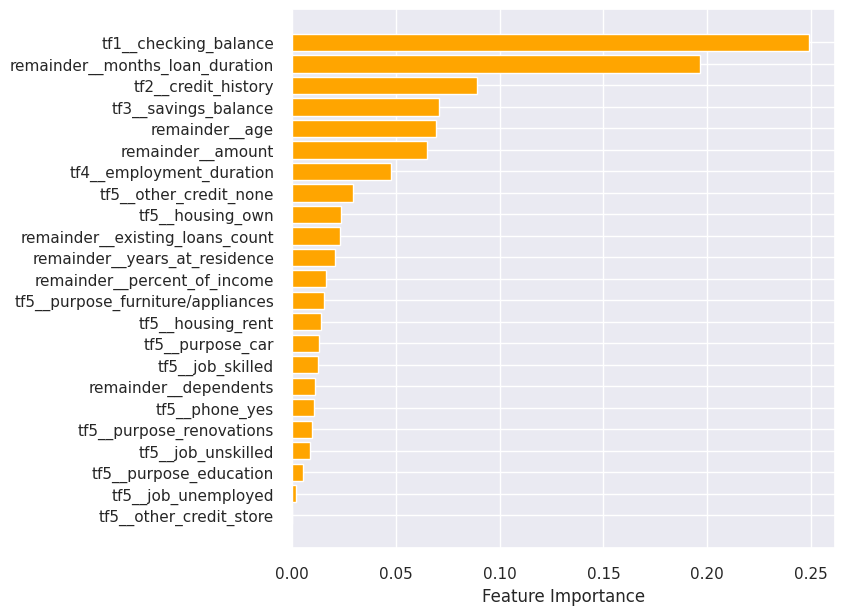

In [ ]:
sort = rf_tuned.feature_importances_.argsort()
plt.barh(X_test.columns[sort], rf_tuned.feature_importances_[sort], color='orange')
plt.xlabel("Feature Importance")

**Observations:**

- The above barplot shows that **checking_balance is the most important feature for the Tuned Random Forest Model** to predict the default customer because we can observe that checking_balance had the highest feature importance value of all the features.
- months_loan_duration has feature importance values greater than 0.1 , which implies that these features are also important for the model's predictions.
- credit_history, savings_balance, age and amount have feature importance values above 0.05 which also contributes to the model's performance.
- Rest of the values has feature importance less than 0.05.

### **Conclusions:**

- After experimenting with several models, we were able to **identify the key factors influencing the 'default' status**.
- The final model, **a tuned Random Forest Model**, has the **highest test recall value for class 'yes' (0.67) with training accuracy of 77% and test accuracy of 67%**. The bank can use this model to predict whether or not a customer will default by further trying to fine-tune the algorithm with different set of parameter values.